# Ramsey RF far frequency scan

This notebook loads the CPU V3b scan over a wide RF-frequency range to
show the Ramsey fringe response away from resonance. The scan uses the
current production reduced-basis setting: `K=24`, `basis_dt=10 us`,
`dt_fine=0.05 us`, and no GPU methods.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (9, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})

def data_path(name):
    candidates = [
        Path("benchmarks") / "_cache" / name,
        Path("examples") / "ramsey_rf" / "benchmarks" / "_cache" / name,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(name)

In [2]:
data = np.load(data_path("v3b_far_frequency_scan_k24_basis10.npz"))
freqs = data["freqs"]
offsets = data["offsets"]
survival = data["survival"]
excitation = 1.0 - survival
fringe_hz = float(data["fringe_hz"])
detuning_hz = offsets * fringe_hz

summary = {
    "points": len(freqs),
    "range_fringes": (float(offsets.min()), float(offsets.max())),
    "range_hz": (float(detuning_hz.min()), float(detuning_hz.max())),
    "elapsed_min": float(data["elapsed_s"]) / 60.0,
    "K": int(data["K"]),
    "basis_dt_us": float(data["basis_dt_us"]),
    "survival_min": float(survival.min()),
    "survival_max": float(survival.max()),
    "excitation_max": float(excitation.max()),
}
summary

{'points': 161,
 'range_fringes': (-10.0, 10.0),
 'range_hz': (-736.0, 736.0),
 'elapsed_min': 12.819474505000592,
 'K': 24,
 'basis_dt_us': 10.0,
 'survival_min': 0.00284533865255069,
 'survival_max': 0.999860138075204,
 'excitation_max': 0.9971546613474493}

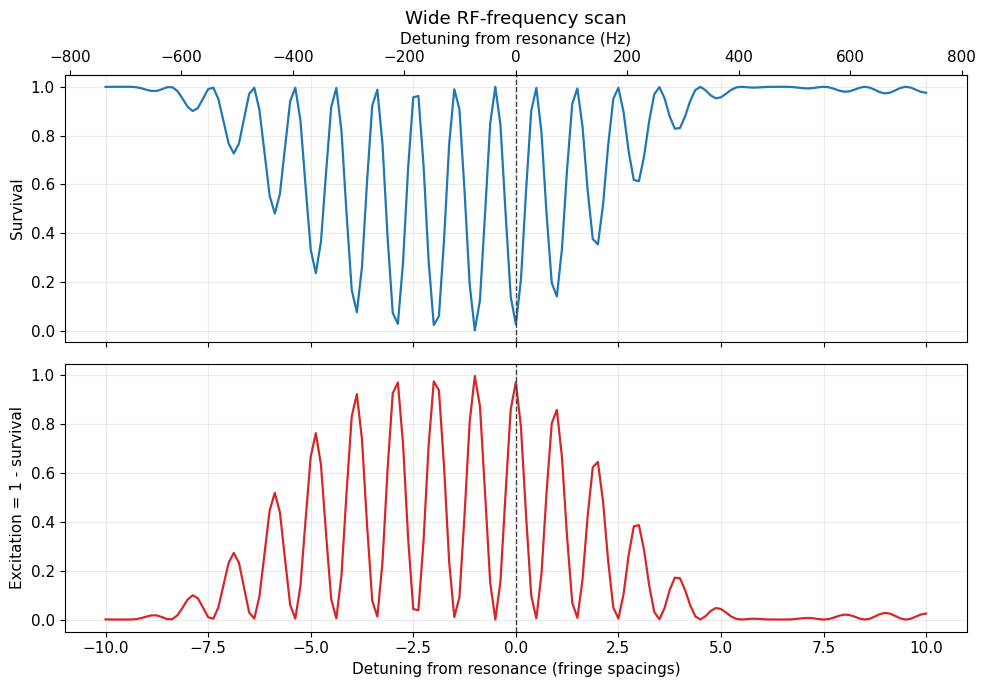

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axes[0].plot(offsets, survival, color="tab:blue", lw=1.6)
axes[0].axvline(0, color="0.25", lw=1, ls="--")
axes[0].set_ylabel("Survival")
axes[0].set_title("Wide RF-frequency scan")

axes[1].plot(offsets, excitation, color="tab:red", lw=1.6)
axes[1].axvline(0, color="0.25", lw=1, ls="--")
axes[1].set_xlabel("Detuning from resonance (fringe spacings)")
axes[1].set_ylabel("Excitation = 1 - survival")

top = axes[0].secondary_xaxis(
    "top",
    functions=(lambda x: x * fringe_hz, lambda x: x / fringe_hz),
)
top.set_xlabel("Detuning from resonance (Hz)")

fig.tight_layout()

In [4]:
central = np.abs(offsets) <= 2
outer = np.abs(offsets) >= 8
print(f"Central |offset| <= 2 fringes: excitation max = {excitation[central].max():.6f}")
print(f"Outer |offset| >= 8 fringes: excitation max = {excitation[outer].max():.6f}")
print(f"Outer |offset| >= 8 fringes: excitation min = {excitation[outer].min():.6f}")
print(f"Scan elapsed = {float(data['elapsed_s']) / 60:.2f} min")

Central |offset| <= 2 fringes: excitation max = 0.997155
Outer |offset| >= 8 fringes: excitation max = 0.082034
Outer |offset| >= 8 fringes: excitation min = 0.000140
Scan elapsed = 12.82 min


The lower panel is the useful view for the far-detuned behavior:
excitation is large near the Ramsey resonance structure and falls back
toward zero when the RF is far enough detuned that the pulses no longer
transfer much population.